# ABSA Aspect-Sentiment Analysis: NYC Tripadvisor Reviews (5000 Sample)

This notebook provides a comprehensive analysis of aspect-based sentiment (ABSA) results for NYC Tripadvisor reviews, including descriptive statistics, VADER sanity checks, and deep dives into the most frequent aspects.

## 1. Setup: Imports and Data Path

Import all dependencies and locate the dataset using the project root utility.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from matplotlib.colors import ListedColormap

# =============================================================================
# DETECT PROJECT ROOT AND SET DATA PATH
# =============================================================================

# Import find_project_root from project utilities
# This function walks up the directory tree looking for a .projectroot marker file
from scripts.project_utils import find_project_root

project_root = find_project_root()
dataset_path = project_root / "data" / "processed" / "tripadvisor_nyc_absa_llm_full_5000_staged.parquet"
print(f"Project root: {project_root}")
print(f"Dataset path: {dataset_path}")


Project root detected:
  /Users/kristinakogan/code/TinaKgn/absa-tourism-reviews
If correct, continue to next cell
If wrong, see commented line below to override

Project root: /Users/kristinakogan/code/TinaKgn/absa-tourism-reviews
Dataset path: /Users/kristinakogan/code/TinaKgn/absa-tourism-reviews/data/processed/tripadvisor_nyc_absa_llm_full_5000_staged.parquet


## 2. Load Dataset from Silver Staged Folder

Load the NYC Tripadvisor ABSA 5000-sample dataset using pandas.

In [2]:
# Load the LLM aspect-sentiment results produced by notebook 02
# The 'llm_aspects' column contains a JSON string of aspect->sentiment mappings
df = pd.read_parquet(dataset_path)
print(f"Loaded {len(df):,} rows.")
df.head()


Loaded 5,000 rows.


,orig_index,rvw_id_pr,usr_id_pr,lst_id_pr,rvw_text_pr,rvw_text_flags_pr,rvw_vader_pr,rvw_year_pr,rvw_month_pr,lst_lat_pr,lst_lon_pr,lst_metro_code_pr,is_accommodation_pr,is_restaurant_pr,is_nightlife_pr,is_entertainment_pr,is_tours_pr,is_events_pr,llm_aspects
0,67961,4187855025034601237,125711495911142695,7216442717905379776,"Because of problems with BA at Heathrow, we di...",emoji:0|punct:0|space:0|long:1,0.9962,2015,1,40.769001,-73.982948,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."
1,62951,16030209335468258604,7148981648026715854,12900033009701489607,I have been here several times and have found ...,emoji:0|punct:0|space:0|long:0,0.9789,2015,1,40.764702,-73.968956,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."
2,52698,8756536453710533938,12773076195504996377,2708177658169265045,This next comment is not only a reflection of ...,emoji:0|punct:2|space:0|long:0,0.9706,2015,1,40.752201,-73.981155,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."
3,36461,4714873220144592321,8120103518546386781,10697613456557793400,Nice hotel thats central in location to many h...,emoji:0|punct:0|space:0|long:0,0.9832,2015,1,40.720901,-74.005623,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."
4,69689,14787115221043274069,14320649791029870421,12307477088580125724,Found ourselves stranded in NYC because of sno...,emoji:0|punct:2|space:0|long:0,0.9829,2015,1,40.751301,-73.984573,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."


## 3. Descriptive Statistics of Dataset

Compute and display descriptive statistics for aspects, sentiments, and review lengths.

Aspect count:


aspect
accommodation quality    4994
value for money          4867
staff friendliness       4801
service quality          4294
location                 4264
room size                4008
atmosphere               3437
cleanliness              3399
food quality             1531
noise level              1338
drink quality            1132
tours                     855
wait time                 440
crowding                  324
availability              257
Name: count, dtype: int64


Sentiment distribution:


sentiment
Positive    28633
Neutral      7020
Negative     2562
None         1726
Name: count, dtype: int64

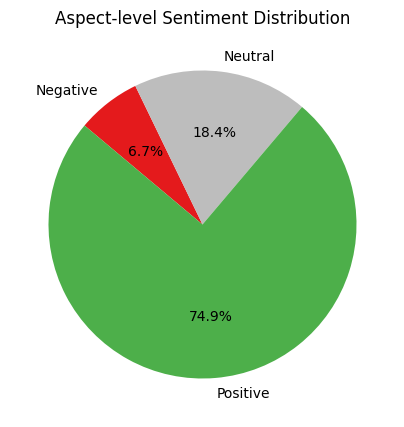

In [3]:
# Flatten aspect-sentiment pairs from all reviews into a flat DataFrame.
# Each row = one (aspect, sentiment) observation from one review.
aspect_sentiment_records = []
for _, row in df.iterrows():
    aspects = row['llm_aspects']
    if isinstance(aspects, str):
        try:
            aspects = json.loads(aspects)
        except Exception:
            continue
    if not isinstance(aspects, dict):
        continue
    for aspect, payload in aspects.items():
        sentiment = str(payload.get('sentiment', '')).strip().capitalize()
        aspect_sentiment_records.append({
            'aspect': aspect,
            'sentiment': sentiment,
            'review_text': row.get('rvw_text_pr', '')
        })

aspect_sentiment_df = pd.DataFrame(aspect_sentiment_records)

print("Aspect count:")
display(aspect_sentiment_df['aspect'].value_counts().head(20))
print("\nSentiment distribution:")
display(aspect_sentiment_df['sentiment'].value_counts())

# Pie chart: overall sentiment distribution
sentiment_order = ['Negative', 'Neutral', 'Positive']
color_map = {'Positive': '#4daf4a', 'Neutral': '#bdbdbd', 'Negative': '#e41a1c'}
sentiment_counts = aspect_sentiment_df['sentiment'].value_counts()
sentiment_counts = sentiment_counts[[s for s in sentiment_order if s in sentiment_counts.index]]
plt.figure(figsize=(5, 5))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=[color_map[s] for s in sentiment_counts.index],
    startangle=140,
    counterclock=False
)
plt.title('Aspect-level Sentiment Distribution')
plt.show()


## 4. Sanity Check: Compare ABSA Sentiment Scores with VADER Scores

Compare ABSA sentiment with VADER sentiment using scatter plots and correlation metrics.

VADER vs ABSA SENTIMENT COMPARISON

📊 COVERAGE STATISTICS
--------------------------------------------------------------------------------
Total reviews in sample: 5000
Reviews with ≥1 aspect detected: 5000 (100.0%)
Total aspect detections: 39941
Average aspects per review (among those with aspects): 7.99

🎯 ASPECTS DETECTED (top 10)
--------------------------------------------------------------------------------
  accommodation quality......... 4994 detections
  value for money............... 4867 detections
  staff friendliness............ 4801 detections
  service quality............... 4294 detections
  location...................... 4264 detections
  room size..................... 4008 detections
  atmosphere.................... 3437 detections
  cleanliness................... 3399 detections
  food quality.................. 1531 detections
  noise level................... 1338 detections

📈 VADER SENTIMENT DISTRIBUTION (review level)
----------------------------------------------

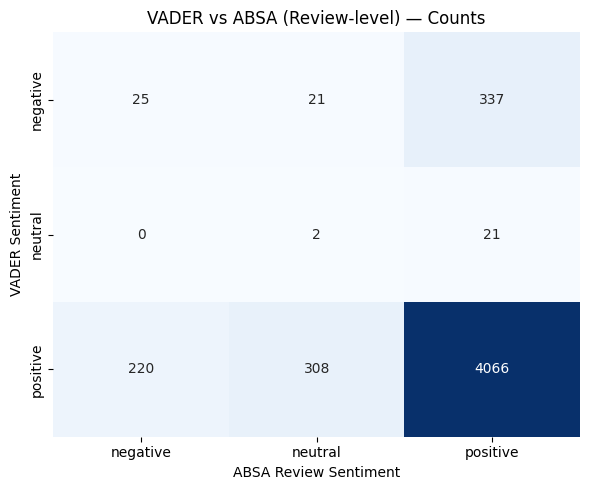

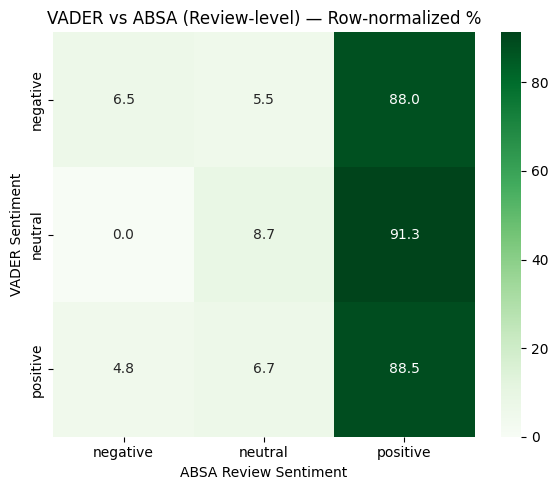

In [4]:
# === VADER vs ABSA Comparison Analysis ===
print("=" * 80)
print("VADER vs ABSA SENTIMENT COMPARISON")
print("=" * 80)

# Classify VADER compound score into sentiment label
def vader_sentiment(score):
    if pd.isna(score):
        return 'unknown'
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_sentiment'] = df['rvw_vader_pr'].apply(vader_sentiment)

# Helper: decide whether an aspect entry has a confirmed detection
def _is_aspect_detected(details):
    if isinstance(details, dict):
        if 'present' in details:
            return bool(details.get('present'))
        sentiment = details.get('sentiment')
        confidence = details.get('confidence')
        if sentiment and str(sentiment).lower() not in ('unknown', 'none'):
            return True
        if confidence is not None and not (isinstance(confidence, float) and np.isnan(confidence)):
            return True
        return False
    return False

aspect_records = []
for idx, row in df.iterrows():
    absa_aspects = row['llm_aspects']
    vader_sent = row.get('vader_sentiment')

    if isinstance(absa_aspects, str):
        try:
            absa_aspects = json.loads(absa_aspects)
        except Exception:
            continue

    if isinstance(absa_aspects, dict):
        for aspect, details in absa_aspects.items():
            if _is_aspect_detected(details):
                if not isinstance(details, dict):
                    details = {}
                aspect_records.append({
                    'orig_index': idx,
                    'aspect': aspect,
                    'absa_sentiment': details.get('sentiment', 'unknown'),
                    'vader_sentiment': vader_sent,
                    'confidence': details.get('confidence', np.nan)
                })

aspect_comparison_df = pd.DataFrame(aspect_records)

# Helper: count detected aspects per review
def _count_detected(aspects):
    if isinstance(aspects, str):
        try:
            aspects = json.loads(aspects)
        except Exception:
            return 0
    if not isinstance(aspects, dict):
        return 0
    return sum(1 for v in aspects.values() if _is_aspect_detected(v))

# Coverage statistics
total_reviews = len(df)
detected_counts = df['llm_aspects'].apply(_count_detected)
reviews_with_aspects = int(detected_counts.gt(0).sum())
total_aspect_detections = len(aspect_records)
avg_aspects_per_detected_review = total_aspect_detections / max(1, reviews_with_aspects)

print(f"\n📊 COVERAGE STATISTICS")
print("-" * 80)
print(f"Total reviews in sample: {total_reviews}")
print(f"Reviews with ≥1 aspect detected: {reviews_with_aspects} ({100 * reviews_with_aspects / max(1, total_reviews):.1f}%)")
print(f"Total aspect detections: {total_aspect_detections}")
print(f"Average aspects per review (among those with aspects): {avg_aspects_per_detected_review:.2f}")

print(f"\n🎯 ASPECTS DETECTED (top 10)")
print("-" * 80)
if total_aspect_detections > 0:
    top_aspects = aspect_comparison_df['aspect'].value_counts().head(10)
    for aspect, count in top_aspects.items():
        print(f"  {aspect:.<30} {count:>4} detections")
else:
    print("  (no detected aspects found)")

print(f"\n📈 VADER SENTIMENT DISTRIBUTION (review level)")
print("-" * 80)
vader_dist = df['vader_sentiment'].value_counts().sort_index()
for sent, count in vader_dist.items():
    pct = 100 * count / total_reviews
    print(f"  {sent:.<20} {count:>4} ({pct:>5.1f}%)")

print(f"\n📈 ABSA SENTIMENT DISTRIBUTION (aspect-level)")
print("-" * 80)
if total_aspect_detections > 0:
    absa_dist = aspect_comparison_df['absa_sentiment'].value_counts().sort_index()
    for sent, count in absa_dist.items():
        pct = 100 * count / total_aspect_detections
        print(f"  {sent:.<20} {count:>4} ({pct:>5.1f}%)")
else:
    print("  (no aspect-level sentiments to show)")

print(f"\n🔍 ASPECT-LEVEL: ABSA SENTIMENT vs CONFIDENCE")
print("-" * 80)
print("Distribution of ABSA model confidence by sentiment label.")
print()
if total_aspect_detections > 0:
    unique_sentiments = sorted([
        s for s in aspect_comparison_df['absa_sentiment'].unique()
        if isinstance(s, str) and s.strip() != ''
    ])
    for sent in unique_sentiments:
        sent_data = aspect_comparison_df[aspect_comparison_df['absa_sentiment'] == sent]['confidence']
        if len(sent_data) > 0:
            print(f"  {sent:.<15} | Count: {len(sent_data):>4} | Mean conf: {sent_data.mean():.3f} | Min: {sent_data.min():.3f} | Max: {sent_data.max():.3f}")
else:
    print("  (no aspect-level sentiments to analyze)")

# Build review-level ABSA mode sentiment (most common aspect sentiment per review)
print(f"\n🔍 REVIEW-LEVEL: VADER vs REVIEW-AVERAGE ABSA SENTIMENT")
print("-" * 80)
print("For each review, compute the mode ABSA sentiment across all detected aspects,")
print("then compare to the review-level VADER sentiment.")
print()

review_absa_sentiments = {}
for idx, row in df.iterrows():
    absa_aspects = row['llm_aspects']
    if isinstance(absa_aspects, str):
        try:
            absa_aspects = json.loads(absa_aspects)
        except Exception:
            continue
    if isinstance(absa_aspects, dict):
        detected_sentiments = [
            details.get('sentiment', 'unknown')
            for aspect, details in absa_aspects.items()
            if _is_aspect_detected(details) and isinstance(details, dict)
            and str(details.get('sentiment', '')).lower() not in ('unknown', 'none', '')
        ]
        if detected_sentiments:
            review_absa_sentiments[idx] = Counter(detected_sentiments).most_common(1)[0][0]

review_comparison_records = [
    {
        'orig_index': idx,
        'vader_sentiment': df.loc[idx, 'vader_sentiment'],
        'absa_review_sentiment': absa_sent,
        'match': df.loc[idx, 'vader_sentiment'] == absa_sent
    }
    for idx, absa_sent in review_absa_sentiments.items()
]

if review_comparison_records:
    review_comparison_df = pd.DataFrame(review_comparison_records)

    # Confusion matrix: counts
    conf_matrix = pd.crosstab(
        review_comparison_df['vader_sentiment'],
        review_comparison_df['absa_review_sentiment'],
        margins=False
    )
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("VADER vs ABSA (Review-level) — Counts")
    plt.xlabel("ABSA Review Sentiment")
    plt.ylabel("VADER Sentiment")
    plt.tight_layout()
    plt.show()

    # Confusion matrix: row-normalised percentages
    conf_pct = pd.crosstab(
        review_comparison_df['vader_sentiment'],
        review_comparison_df['absa_review_sentiment'],
        normalize='index'
    ).fillna(0)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_pct * 100, annot=True, fmt=".1f", cmap="Greens", cbar=True)
    plt.title("VADER vs ABSA (Review-level) — Row-normalized %")
    plt.xlabel("ABSA Review Sentiment")
    plt.ylabel("VADER Sentiment")
    plt.tight_layout()
    plt.show()


## 5. Aspect Distribution Bar Chart

Visualize the frequency of each aspect in the dataset.

/var/folders/2l/8rtkcb8x1lq1l5hrrsf7kghw0000gn/T/ipykernel_72149/2054617778.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette='Blues_r')


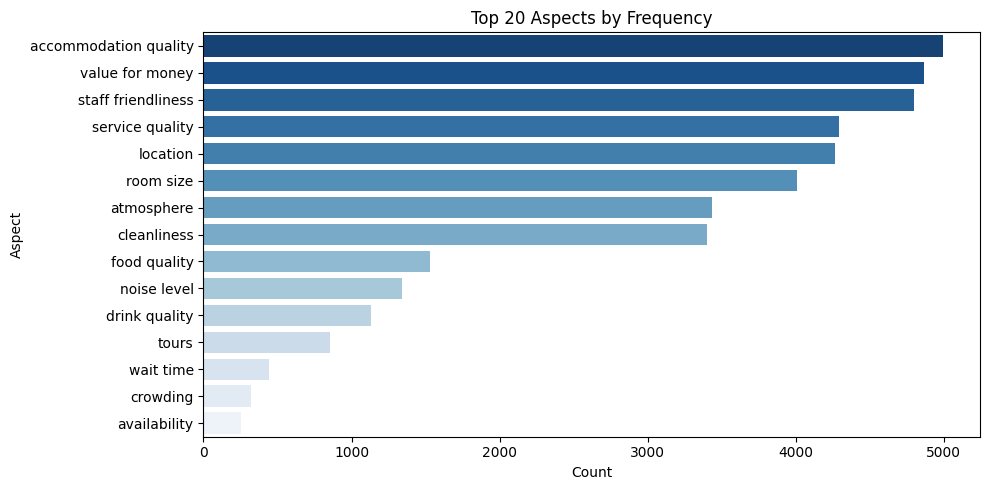

In [5]:
# Bar chart: aspect frequency (top N aspects by number of mentions)
top_n = 20
aspect_counts = aspect_sentiment_df['aspect'].value_counts().head(top_n)
plt.figure(figsize=(10, 5))
sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette='Blues_r')
plt.xlabel('Count')
plt.ylabel('Aspect')
plt.title(f'Top {top_n} Aspects by Frequency')
plt.tight_layout()
plt.show()


## 6. Sentiment per Aspect Bar Chart

Plot the distribution of sentiment (positive, neutral, negative) for each aspect.

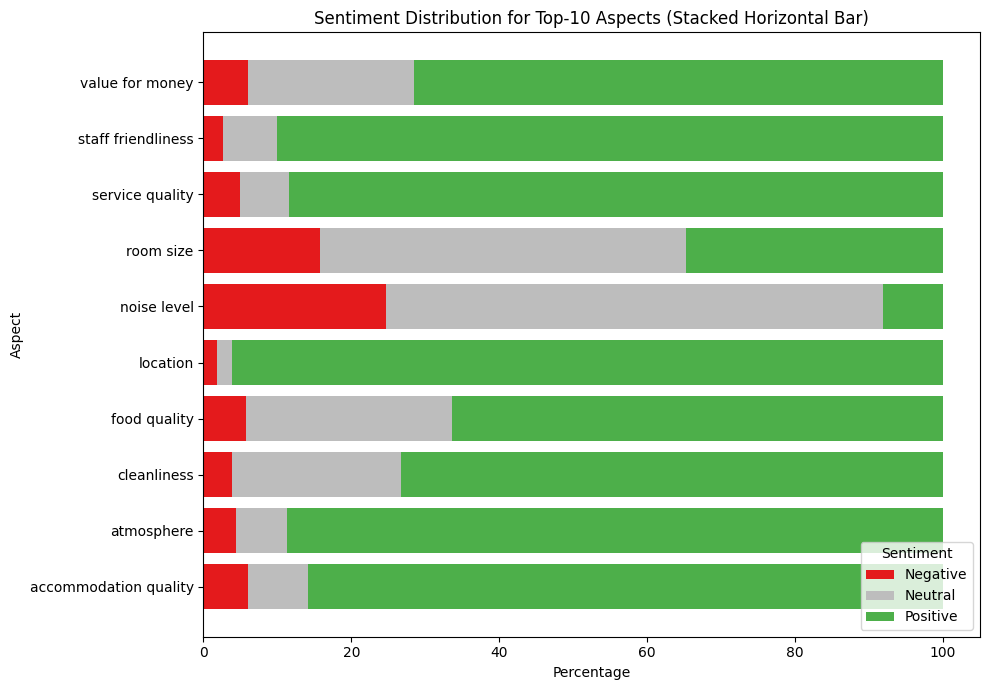

In [6]:
# Stacked horizontal bar chart: sentiment distribution per aspect
top_aspects = aspect_sentiment_df['aspect'].value_counts().head(10).index
sentiment_order = ['Negative', 'Neutral', 'Positive']
color_map = {'Positive': '#4daf4a', 'Neutral': '#bdbdbd', 'Negative': '#e41a1c'}

bar_data = (
    aspect_sentiment_df[aspect_sentiment_df['aspect'].isin(top_aspects)]
    .groupby(['aspect', 'sentiment']).size()
    .unstack(fill_value=0)
)

# Ensure all sentiment columns exist and are in the correct order
for col in sentiment_order:
    if col not in bar_data.columns:
        bar_data[col] = 0
bar_data = bar_data[sentiment_order]

# Row-normalise to percentages
bar_pct = bar_data.div(bar_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 7))
left = np.zeros(len(bar_pct))
for sentiment in sentiment_order:
    values = bar_pct[sentiment].values
    ax.barh(bar_pct.index, values, left=left, label=sentiment, color=color_map[sentiment])
    left += values

ax.set_xlabel('Percentage')
ax.set_ylabel('Aspect')
ax.set_title('Sentiment Distribution for Top-10 Aspects (Stacked Horizontal Bar)')
ax.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
plt.show()


## 7. Sentiment per Aspect Heatmap

Generate a heatmap with aspects and sentiment, colored from green (positive) to red (negative).

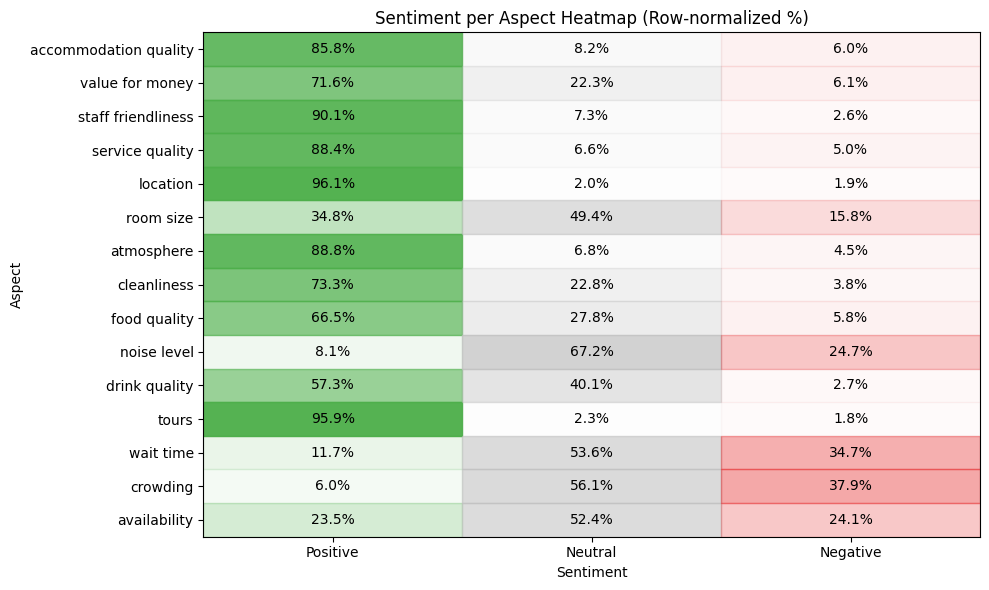

In [7]:
# Heatmap: row-normalised sentiment percentages per aspect
heatmap_data = aspect_sentiment_df.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)
top_heatmap_aspects = aspect_sentiment_df['aspect'].value_counts().head(15).index
heatmap_data = heatmap_data.loc[top_heatmap_aspects]

# Ensure all sentiment columns exist in fixed order
sentiment_order = ['Positive', 'Neutral', 'Negative']
for col in sentiment_order:
    if col not in heatmap_data.columns:
        heatmap_data[col] = 0
heatmap_data = heatmap_data[sentiment_order]

# Row-normalise to percentages
row_sums = heatmap_data.sum(axis=1).replace(0, np.nan)
heatmap_pct = heatmap_data.div(row_sums, axis=0).fillna(0) * 100

# Custom colormap: green (positive), grey (neutral), red (negative)
cmap = ListedColormap(['#4daf4a', '#bdbdbd', '#e41a1c'])
norm = plt.Normalize(0, 100)

fig, ax = plt.subplots(figsize=(10, 6))
for i, col in enumerate(sentiment_order):
    for j, val in enumerate(heatmap_pct[col].values):
        ax.add_patch(plt.Rectangle((i, j), 1, 1, color=cmap(i), alpha=norm(val)))

# Overlay percentage annotations
for i, aspect in enumerate(heatmap_pct.index):
    for j, col in enumerate(sentiment_order):
        val = heatmap_pct.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f"{val:.1f}%", va='center', ha='center', color='black', fontsize=10)

ax.set_xticks(np.arange(len(sentiment_order)) + 0.5)
ax.set_xticklabels(sentiment_order)
ax.set_yticks(np.arange(len(heatmap_pct.index)) + 0.5)
ax.set_yticklabels(heatmap_pct.index)
ax.set_xlim(0, len(sentiment_order))
ax.set_ylim(0, len(heatmap_pct.index))
ax.invert_yaxis()
ax.set_xlabel('Sentiment')
ax.set_ylabel('Aspect')
ax.set_title('Sentiment per Aspect Heatmap (Row-normalized %)')
plt.tight_layout()
plt.show()


## 8. Word Clouds for Top-5 Aspects

Generate word clouds for the review texts associated with each of the top-5 aspects.

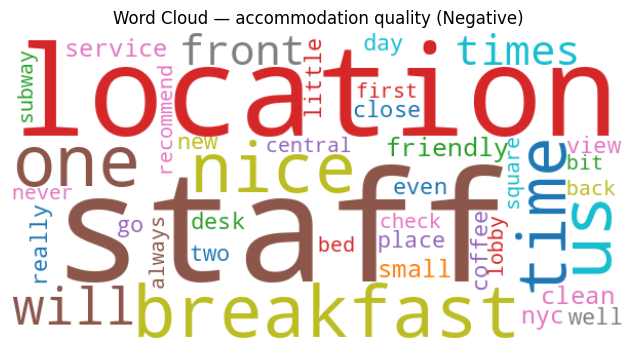

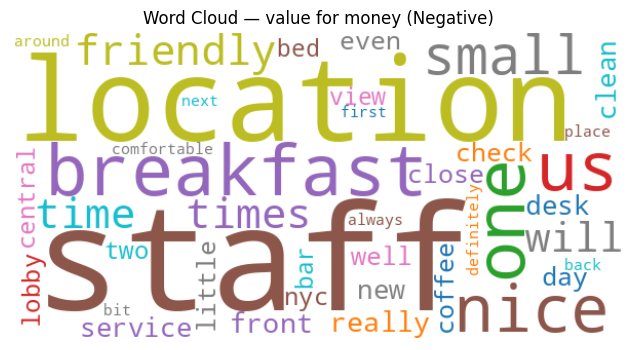

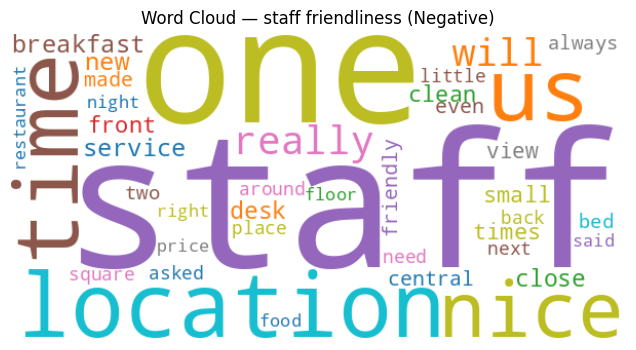

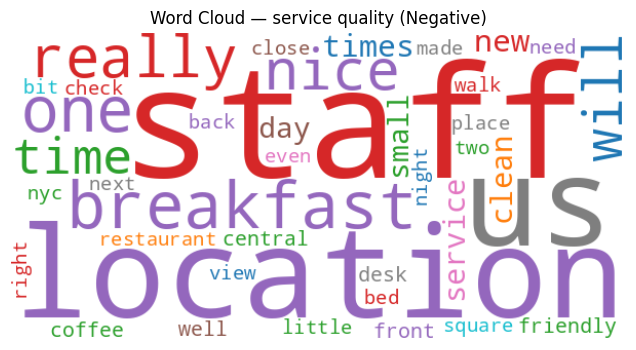

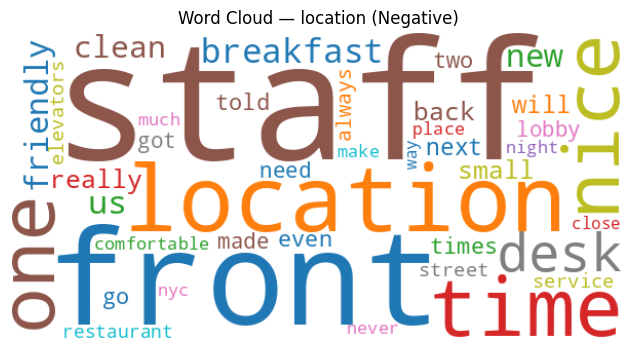

In [8]:
# Word clouds for top-5 aspects
# Set sentiment_filter to 'Positive', 'Negative', or None for all sentiments
custom_stopwords = {'hotel', 'room', 'rooms', 'stay', 'stayed', 'great', 'good'}
all_stopwords = STOPWORDS.union(custom_stopwords)
word_freq_threshold = 5   # Minimum word frequency to appear in the cloud
max_words = 40            # Maximum number of words to display
sentiment_filter = "Negative"

top5_aspects = aspect_sentiment_df['aspect'].value_counts().head(5).index.tolist()

for aspect in top5_aspects:
    if sentiment_filter:
        filtered_df = aspect_sentiment_df[
            (aspect_sentiment_df['aspect'] == aspect) &
            (aspect_sentiment_df['sentiment'] == sentiment_filter)
        ]
    else:
        filtered_df = aspect_sentiment_df[aspect_sentiment_df['aspect'] == aspect]

    texts = filtered_df['review_text'].dropna().astype(str)
    if texts.empty:
        print(f"No reviews for aspect: {aspect} (sentiment: {sentiment_filter or 'any'})")
        continue

    text_blob = ' '.join(texts)
    words = [w.lower() for w in text_blob.split() if w.isalpha() and w.lower() not in all_stopwords]
    word_counts = Counter(words)
    filtered_word_counts = dict(
        Counter({w: c for w, c in word_counts.items() if c >= word_freq_threshold}).most_common(max_words)
    )

    if not filtered_word_counts:
        print(f"No words above threshold for aspect: {aspect} (sentiment: {sentiment_filter or 'any'})")
        continue

    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap='tab10',
        stopwords=all_stopwords,
        max_words=max_words
    ).generate_from_frequencies(filtered_word_counts)

    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud — {aspect} ({sentiment_filter or 'All sentiments'})")
    plt.show()
